<a href="https://colab.research.google.com/github/bonfito/GroupF/blob/GenerativeMethod/Notebooks/pipelineDiffPIR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
base = Path('/content/drive/MyDrive/Imaging')
print('Imaging/ esiste:', base.exists())
print('Contenuto Imaging/:', [p.name for p in base.iterdir()])

# Cerca le immagini della retina
pngs = list(base.rglob('*.png'))
print('\nPNG trovati in Imaging/:', len(pngs))
if pngs:
    print('Percorso esempio:', pngs[0])

Mounted at /content/drive
Imaging/ esiste: True
Contenuto Imaging/: ['Mayo', 'IPPy', 'weights', 'homework2.ipynb', 'project', 'homework2-addestramento.ipynb']

PNG trovati in Imaging/: 8324
Percorso esempio: /content/drive/MyDrive/Imaging/project/data/retina/retinal_data/images/retinal_003195.png


# Setup


In [2]:
import sys, glob
from pathlib import Path

book_root = Path('/content/drive/MyDrive/Imaging')
ipp_root = book_root / 'IPPy'
data_root = book_root / 'project' / 'data' / 'retina' / 'retinal_data' / 'images'
weights_dir = book_root / 'project' / 'weights'
weights_dir.mkdir(parents=True, exist_ok=True)

sys.path.append(str(ipp_root))
import types
sys.modules['astra'] = types.ModuleType('astra')

import torch
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms

import operators
from utilities import gaussian_noise, get_device
from nn.diffusion import DiffusionUNet, EMA, cosine_beta_schedule, extract, denormalize_to_01

device = get_device()
print('Device:', device)
print('Immagini disponibili:', len(list(data_root.glob('*.png'))))

Device: cuda
Immagini disponibili: 4162


# Split in train val e test

In [3]:

#proporzioni 70/15/15 -> 2800 / 600 / 600

MAX_IMAGES = 4000

# Stesso identico elenco file dei colleghi
fname_list = sorted(glob.glob(f"{data_root}/**/*.png", recursive=True))[:MAX_IMAGES]
print('Immagini totali considerate:', len(fname_list))

n_total = len(fname_list)
n_train = int(0.70 * n_total)
n_val   = int(0.15 * n_total)
n_test  = n_total - n_train - n_val

# random_split lavora su indici 0..n_total-1, con lo stesso generatore seed 0
indices = list(range(n_total))
train_idx, val_idx, test_idx = random_split(
    indices, [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(0),
)

# Liste di percorsi per ciascuno split
train_files = [fname_list[i] for i in train_idx]
val_files   = [fname_list[i] for i in val_idx]
test_files  = [fname_list[i] for i in test_idx]

print(f'Train: {len(train_files)} | Val: {len(val_files)} | Test: {len(test_files)}')

Immagini totali considerate: 4000
Train: 2800 | Val: 600 | Test: 600


# Class del dataset e operatore K

Le immagini vengono ridimensionate a 256x256 come da indicazioni del progetto.
Normalizzazione in [-1,1] perche Diffpir lavora in quel range.

In [7]:
class RetinaDataset(Dataset):
    def __init__(self, file_list, data_shape=256):
        super().__init__()
        self.fname_list = file_list
        self.transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((data_shape, data_shape), antialias=True),
            transforms.ToTensor(),
            transforms.Normalize((0.5,), (0.5,)),   # [-1,1] per DiffPIR
        ])
    def __len__(self):
        return len(self.fname_list)
    def __getitem__(self, idx):
        x = Image.open(self.fname_list[idx])
        return self.transform(x)

train_dataset = RetinaDataset(train_files, data_shape=256)
val_dataset   = RetinaDataset(val_files,   data_shape=256)
test_dataset  = RetinaDataset(test_files,  data_shape=256)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print(f'Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}')

K = operators.Blurring(img_shape=(256, 256), kernel_type='motion',
                       kernel_size=9, motion_angle=45)
print('Operatore K: motion blur 45°, kernel 9')

Train: 2800 | Val: 600 | Test: 600
Operatore K: motion blur 45°, kernel 9


# Livelli di Rumore



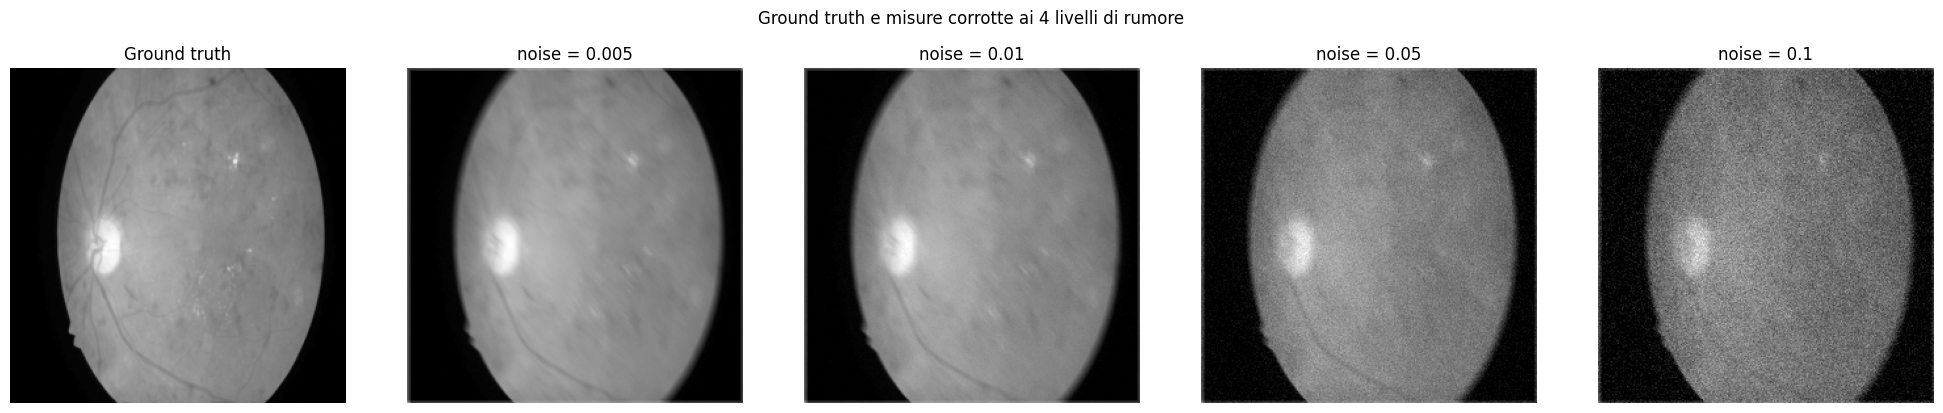

In [8]:
noise_levels = [0.005, 0.01, 0.05, 0.1]

with torch.no_grad():
    x_true = test_dataset[0].unsqueeze(0).to(device)

fig, axes = plt.subplots(1, len(noise_levels) + 1, figsize=(20, 4))

axes[0].imshow(denormalize_to_01(x_true).cpu().squeeze(), cmap='gray')
axes[0].set_title('Ground truth'); axes[0].axis('off')

for i, nl in enumerate(noise_levels):
    with torch.no_grad():
        y_delta = K(x_true) + nl * torch.randn_like(x_true)   # formula dei prof (EX6/EX7)
    axes[i+1].imshow(denormalize_to_01(y_delta).cpu().squeeze(), cmap='gray')
    axes[i+1].set_title(f'noise = {nl}'); axes[i+1].axis('off')

plt.suptitle('Ground truth e misure corrotte ai 4 livelli di rumore', y=1.02)
plt.tight_layout(); plt.show()